# Spotify Hit Song Analysis

## Business Question

What factors are associated with a song becoming one of Spotify's most streamed tracks of 2023?

## Data Cleaning

### Importing Packages & Dataset

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("spotify-2023.csv", encoding = "latin1")

### Finding Amount of Rows in Dataset

In [3]:
df.shape

(953, 24)

### Deleting Duplicates

In [4]:
df = df.drop_duplicates(
    subset=["track_name", "artist(s)_name"]
)

In [5]:
df.shape

(949, 24)

In [6]:
df.duplicated(
    subset=["track_name", "artist(s)_name"]
).sum()

np.int64(0)

In [7]:
df.isnull().sum()

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     94
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [8]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='str')

## Defining Hit Songs

In this analysis, hit songs are defined as the top 10% of songs by streams.

In [9]:
df["streams"] = pd.to_numeric(
    df["streams"],
    errors = "coerce"
)

In [10]:
cutoff = df["streams"].quantile(0.90)
print(cutoff)

1302823046.8000002


In [11]:
df["hit_song"] = (
    df["streams"] >= cutoff
).astype(int)

In [12]:
df["hit_song"].value_counts()

hit_song
0    854
1     95
Name: count, dtype: int64

## Hit vs. Non-Hit Songs Analysis

In [13]:
df.groupby("hit_song")[
    [
        "danceability_%",
        "energy_%",
        "valence_%",
        "acousticness_%",
        "artist_count",
        "in_spotify_playlists"
    ]
].mean().round(2)

,danceability_%,energy_%,valence_%,acousticness_%,artist_count,in_spotify_playlists
hit_song,,,,,,
0,67.32,64.24,51.50,27.19,1.59,3445.04
1,63.64,64.55,50.51,26.69,1.32,21008.92


In [14]:
numeric_cols = [
    "streams",
    "artist_count",
    "in_spotify_playlists",
    "in_spotify_charts",
    "in_apple_playlists",
    "in_apple_charts",
    "danceability_%",
    "energy_%",
    "valence_%",
    "acousticness_%"
]
df[numeric_cols].corr()["streams"].sort_values(ascending = False)

streams                 1.000000
in_spotify_playlists    0.790082
in_apple_playlists      0.774347
in_apple_charts         0.320748
in_spotify_charts       0.246201
acousticness_%         -0.004428
energy_%               -0.026376
valence_%              -0.041105
danceability_%         -0.105620
artist_count           -0.136474
Name: streams, dtype: float64

### Playlist Exposure

In [15]:
df["hit_song_label"] = df["hit_song"].map({
    0: "Non-Hit Songs",
    1: "Hit Songs"
})

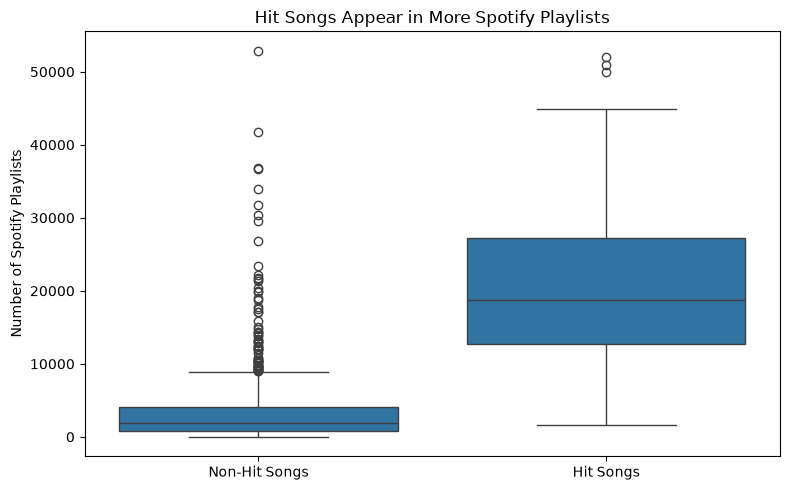

In [16]:
plt.figure(figsize = (8, 5))
sns.boxplot(
    data = df,
    x = "hit_song_label",
    y = "in_spotify_playlists"
)

plt.title("Hit Songs Appear in More Spotify Playlists")
plt.xlabel("")
plt.ylabel("Number of Spotify Playlists")
plt.tight_layout()
plt.savefig(
    "images/playlist_exposure_boxplot.png",
    bbox_inches = "tight"
)
plt.show()

In [17]:
from scipy.stats import ttest_ind

hits = df[df["hit_song"] == 1]["in_spotify_playlists"]
non_hits = df[df["hit_song"] == 0]["in_spotify_playlists"]

t_stat, p_val = ttest_ind(
    hits,
    non_hits,
    equal_var = False
)

print(p_val)

3.1449723753668123e-27


The hypothesis test produced a p-vaue of 3.14×10^−27, which is considerably less than the significance level of 0.05. Thus, we reject the null hypothesis and conclude that hit songs and non-hit songs differ significantly in their average Spotify playlist exposure. We find that hit songs appear in many more playlists than non-hit songs.  

### Danceability

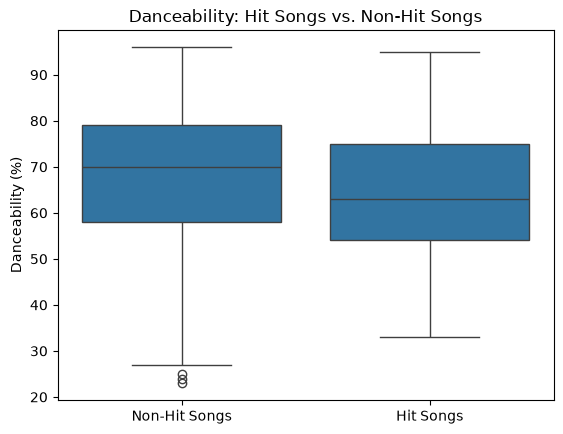

In [21]:
sns.boxplot(
    data = df,
    x = "hit_song_label",
    y = "danceability_%"
)

plt.title("Danceability: Hit Songs vs. Non-Hit Songs")
plt.xlabel("")
plt.ylabel("Danceability (%)")
plt.savefig(
    "images/danceability_boxplot.png",
    bbox_inches = "tight"
)
plt.show()

In [19]:
hits = df[df["hit_song"] == 1]["danceability_%"]
non_hits = df[df["hit_song"] == 0]["danceability_%"]

t_stat, p_val = ttest_ind(
    hits,
    non_hits,
    equal_var = False
)

print(p_val)

0.021936470944406806


The hypothesis test produced a p-vaue of 0.0219, which is less than the significance level of 0.05. Thus, we reject the null hypothesis and conclude that hit songs and non-hit songs differ significantly in their average danceability percentage. We find that hit songs are less danceable than non-hit songs.  

### Energy

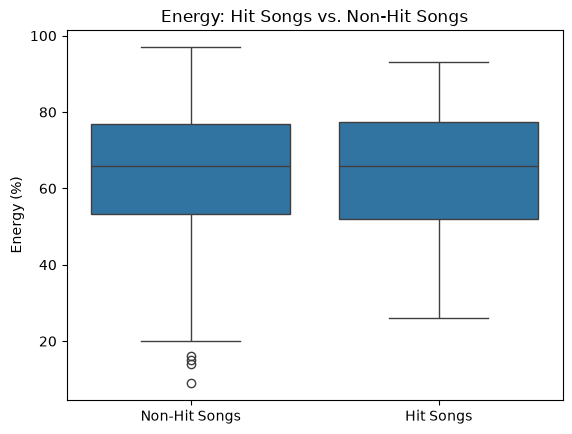

In [22]:
sns.boxplot(
    data = df,
    x = "hit_song_label",
    y = "energy_%"
)

plt.title("Energy: Hit Songs vs. Non-Hit Songs")
plt.xlabel("")
plt.ylabel("Energy (%)")
plt.savefig(
    "images/energy_boxplot.png",
    bbox_inches = "tight"
)
plt.show()

In [23]:
hits = df[df["hit_song"] == 1]["energy_%"]
non_hits = df[df["hit_song"] == 0]["energy_%"]

t_stat, p_val = ttest_ind(
    hits,
    non_hits,
    equal_var = False
)

print(p_val)

0.8624349263251851


The hypothesis test produced a p-vaue of 0.8624, which is considerably higher than the significance level of 0.05. Thus, we fail to reject the null hypothesis and conclude that hit songs and non-hit songs do not differ significantly in their average energy percentage. Based on this, we cannot determine that hit songs differ from non-hit songs in their average energy percentage.

### Valence

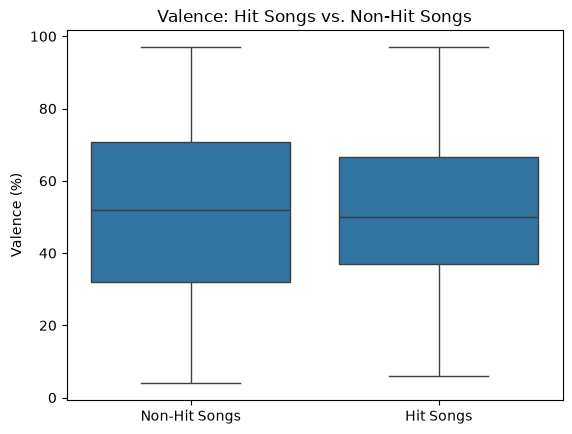

In [24]:
sns.boxplot(
    data = df,
    x = "hit_song_label",
    y = "valence_%"
)

plt.title("Valence: Hit Songs vs. Non-Hit Songs")
plt.xlabel("")
plt.ylabel("Valence (%)")
plt.savefig(
    "images/valence_boxplot.png",
    bbox_inches = "tight"
)
plt.show()

In [25]:
hits = df[df["hit_song"] == 1]["valence_%"]
non_hits = df[df["hit_song"] == 0]["valence_%"]

t_stat, p_val = ttest_ind(
    hits,
    non_hits,
    equal_var = False
)

print(p_val)

0.6908706222430444


The hypothesis test produced a p-vaue of 0.6909, which is considerably higher than the significance level of 0.05. Thus, we fail to reject the null hypothesis and conclude that hit songs and non-hit songs do not differ significantly in their average valence percentage. Based on this, we cannot determine that hit songs differ from non-hit songs in their average energy percentage.

### Artist Collaborations

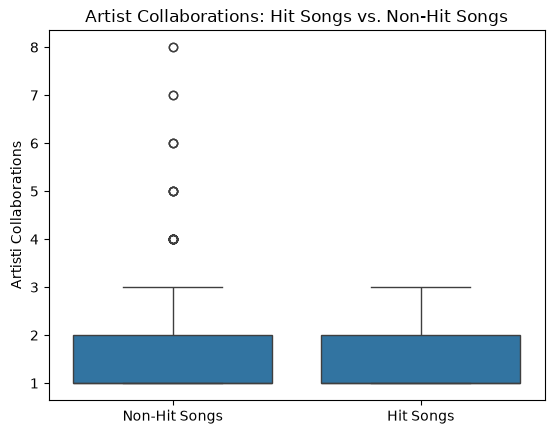

In [26]:
sns.boxplot(
    data = df,
    x = "hit_song_label",
    y = "artist_count"
)

plt.title("Artist Collaborations: Hit Songs vs. Non-Hit Songs")
plt.xlabel("")
plt.ylabel("Artisti Collaborations")
plt.savefig(
    "images/artist_collabs_boxplot.png",
    bbox_inches = "tight"
)
plt.show()

In [27]:
hits = df[df["hit_song"] == 1]["artist_count"]
non_hits = df[df["hit_song"] == 0]["artist_count"]

t_stat, p_val = ttest_ind(
    hits,
    non_hits,
    equal_var = False
)

print(p_val)

5.026299883412606e-05


In [28]:
df.groupby("hit_song_label")["artist_count"].describe()

,count,mean,std,min,25%,50%,75%,max
hit_song_label,,,,,,,,
Hit Songs,95.0,1.315789,0.550882,1.0,1.0,1.0,2.0,3.0
Non-Hit Songs,854.0,1.585480,0.920816,1.0,1.0,1.0,2.0,8.0


The hypothesis test produced a p-vaue of 5.026×10^−27, which is considerably less than the significance level of 0.05. Thus, we reject the null hypothesis and conclude that hit songs and non-hit songs differ significantly in their average number of artist collaborations.
Contrary to what I expected, songs with more collaborating artists were not more likely to be among the most streamed tracks. On average, non-hit songs featured more artist collaborations (1.59) than hit songs (1.32). This suggests that collaborations alone may not be associated with streaming success in the dataset.

### Correlation

In [29]:
numeric_cols = [
    "streams",
    "artist_count",
    "in_spotify_playlists",
    "in_spotify_charts",
    "in_apple_playlists",
    "in_apple_charts",
    "danceability_%",
    "energy_%",
    "valence_%",
    "acousticness_%"
]

corr = df[numeric_cols].corr()

corr["streams"].sort_values(ascending = False)

streams                 1.000000
in_spotify_playlists    0.790082
in_apple_playlists      0.774347
in_apple_charts         0.320748
in_spotify_charts       0.246201
acousticness_%         -0.004428
energy_%               -0.026376
valence_%              -0.041105
danceability_%         -0.105620
artist_count           -0.136474
Name: streams, dtype: float64

Playlist placement showed the strongest relationship with streaming success. Spotify playlist appearances (r = 0.790) and Apple Music playlist appearances (r = 0.774) showed very strong positive correlations with stream counts. This also aligns with my SQL analysis. 
Chart appearances demonstrated somewhat weaker positive relationships with streams (Apple Music charts: r = 0.321 and Spotify charts: r = 0.246), suggesting that playlist inclusion may be a more important driver of song exposure than chart performance.
Audio characteristics such as energy (r = -0.026), valence (r = -0.041), acousticness (r = -0.004), and danceability (r = -0.106) exhibited little to no correlation with stream counts. Artist collaborations also showed only a weak negative relationship with streaming success (r = -0.136).

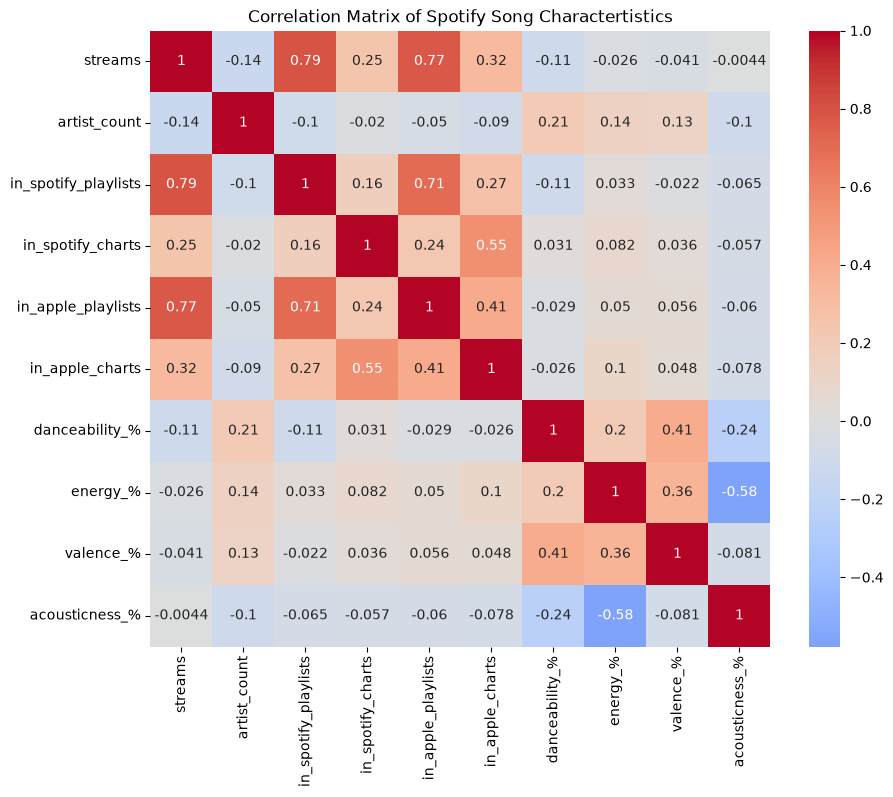

In [30]:
plt.figure(figsize = (10, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot = True,
    cmap = "coolwarm",
    center = 0
)

plt.title("Correlation Matrix of Spotify Song Charactertistics")
plt.savefig(
    "images/correlation_heatmap.png",
    bbox_inches = "tight"
)
plt.show()

# Conclusions

This analysis investigated factors associated with a song becoming one of Spotify's most streamed songs (hit songs) in 2023.

## Key Findings

1. Playlist exposure showed the strongest relationship with streaming success.
2. Songs appearing in more Spotify and Apple Music playlists tended to receive substantially more streams.
3. Danceability showed a statistically significant relationship with streaming success, although the effect was relatively small.
4. Energy and valence exhibited no statistically significant differences between hit songs and non-hit songs. 
5. Contrary to my expectations, songs with more artist collaborations were not more likely to become hit songs.

## Business Implications

Playlist placement appears to be one of the most important factors associated with streaming success. Music platforms and artists seeking to maximize exposure should prioritize playlist inclusion strategies.
Audio features (energy, valence, etc.) appear to play a limited role in explaining streaming success, suggesting that distribution and promotion may be more influential than song charactertistics alone.

# Recommendations

1. Spotify should prioritize playlist placement when promoting emerging artists.
2. Artists should focus on securing playlist inclusion rather than relying solely on collaborations to improve streaming performance.
3. Future analyses should investigate whether playlist placement causes higher streams or whether already-popular songs are more likely to be added to playlists.
4. Additional variables such as marketing activity, social media engagement, and artist popularity may explain streaming success more effectively than audio characteristics alone.

# Limitations

1. Correlation does not imply causation.
2. Playlist placement may increase streams, but highly streamed songs may also be more likely to be added to playlists.
3. Only songs appearing in the Spotify 2023 dataset were analyzed.
4. Other potential influences (marketing campaigns, release timing, artist popularityr, etc.) were not available in this dataset and were not analyzed.